##USE CASE 1: Telecom SIM Activation & Fraud Verification Workflow

In [33]:
!pip install langgraph langchain langchain-google-genai google-generativeai

In [34]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from IPython.display import Image

In [35]:
from google.colab import userdata

# Configure Gemini API
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

In [36]:
# Initializing Gemini LLM
llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [37]:
class TelecomState(TypedDict):
    # Input from the user
    customer_name: str
    document_id: str
    document_type: str
    customer_location: str
    previous_sim_requests: int

    # Output from the workflow
    kyc_status: str
    fraud_risk_classification: str
    final_activation_decision: str

### Step 1: Customer KYC Verification Tool
This tool validates the customer's KYC documents and status.

In [38]:
@tool
def customer_kyc_verification_tool( document_type: str, document_id: str ) -> str:
    """This tool validates customer KYC documents (Aadhaar/PAN) and status.
    """
    if document_type.lower() == "aadhaar" and len(document_id) == 12 and document_id.isdigit():
        if document_id.startswith('123'): #  invalid document
            return "INVALID_DOCUMENT"
        elif document_id.startswith('999'): #  pending verification
            return "PENDING_VERIFICATION"
        else:
            return "VERIFIED"
    elif document_type.lower() == "pan" and len(document_id) == 10 and document_id[:5].isalpha() and document_id[5:9].isdigit() and document_id[9].isalpha():
        if document_id.startswith('ABCDE1234F'): # invalid document
            return "INVALID_DOCUMENT"
        else:
            return "VERIFIED"
    else:
        return "INVALID_DOCUMENT"

In [39]:
def customer_kyc_verification(state: TelecomState) -> TelecomState:
    """Node to perform customer KYC verification."""
    kyc_result = customer_kyc_verification_tool.invoke({
        "document_type": state["document_type"],
        "document_id": state["document_id"]
    })
    state["kyc_status"] = kyc_result
    return state

### Step 2: Fraud Detection Analysis
Analysing customer information and KYC status to classify fraud risk.

In [40]:
def fraud_detection_analysis(state: TelecomState) -> TelecomState:
    """Node to perform fraud detection analysis"""
    prompt = f"""
    Analyze the following customer data to classify the fraud risk as LOW_RISK, MEDIUM_RISK, or HIGH_RISK.
    Return ONLY one of these classifications.

    Customer Name: {state['customer_name']}
    Customer Location: {state['customer_location']}
    Number of Previous SIM Requests: {state['previous_sim_requests']}
    KYC Status: {state['kyc_status']}

    Based on this information, what is the fraud risk classification?
    """
    response = llm.invoke(prompt)
    fraud_classification = response.content.strip().upper()

    # Basic validation for expected output
    if fraud_classification not in ["LOW_RISK", "MEDIUM_RISK", "HIGH_RISK"]:
        if "LOW_RISK" in fraud_classification: fraud_classification = "LOW_RISK"
        elif "MEDIUM_RISK" in fraud_classification: fraud_classification = "MEDIUM_RISK"
        elif "HIGH_RISK" in fraud_classification: fraud_classification = "HIGH_RISK"
        else:
            fraud_classification = "MEDIUM_RISK"

    state["fraud_risk_classification"] = fraud_classification
    return state

### Step 3: Final Activation Decision
Based on the fraud classification, a final decision is made for SIM activation.

In [41]:
def final_activation_decision(state: TelecomState) -> TelecomState:
    """Node to determine the final SIM activation decision."""
    if state["fraud_risk_classification"] == "LOW_RISK":
        decision = "SIM Activated"
    elif state["fraud_risk_classification"] == "MEDIUM_RISK":
        decision = "Manual Review"
    else:  # HIGH_RISK
        decision = "Reject Application"

    state["final_activation_decision"] = decision
    return state

### Compile Telecom SIM Activation Workflow


In [45]:
telecom_graph = StateGraph(TelecomState)

telecom_graph.add_node("kyc_verification", customer_kyc_verification)
telecom_graph.add_node("fraud_detection", fraud_detection_analysis)
telecom_graph.add_node("final_decision", final_activation_decision)

telecom_graph.set_entry_point("kyc_verification")

telecom_graph.add_edge("kyc_verification", "fraud_detection")
telecom_graph.add_edge("fraud_detection", "final_decision")
telecom_graph.add_edge("final_decision", END)

telecom_workflow = telecom_graph.compile()

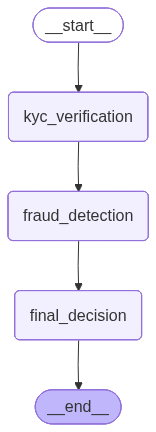

In [46]:
telecom_workflow

### Test the Telecom SIM Activation Workflow

In [48]:
print("\n--- Low Risk Scenario ---")
initial_state_low_risk: TelecomState = {
    "customer_name": "Mubeen",
    "document_id": "123456789012",
    "document_type": "Aadhaar",
    "customer_location": "Urban",
    "previous_sim_requests": 0,
    "kyc_status": "",
    "fraud_risk_classification": "",
    "final_activation_decision": ""
}
result_low_risk = telecom_workflow.invoke(initial_state_low_risk)
print("Low Risk :", result_low_risk)

print("\n--- Medium Risk Scenario (Pending KYC) ---")
initial_state_medium_risk_kyc: TelecomState = {
    "customer_name": "Naveen",
    "document_id": "999111222333", # Simulates PENDING_VERIFICATION
    "document_type": "Aadhaar",
    "customer_location": "Rural",
    "previous_sim_requests": 1,
    "kyc_status": "",
    "fraud_risk_classification": "",
    "final_activation_decision": ""
}
result_medium_risk_kyc = telecom_workflow.invoke(initial_state_medium_risk_kyc)
print("Medium Risk - KYC):", result_medium_risk_kyc)

print("\n--- High Risk Scenario (Invalid Document) ---")
initial_state_high_risk: TelecomState = {
    "customer_name": "Ihsan",
    "document_id": "INVALIDDOC", # Simulates INVALID_DOCUMENT
    "document_type": "PAN",
    "customer_location": "Border Area",
    "previous_sim_requests": 5,
    "kyc_status": "",
    "fraud_risk_classification": "",
    "final_activation_decision": ""
}
result_high_risk = telecom_workflow.invoke(initial_state_high_risk)
print("High Risk :", result_high_risk)


--- Low Risk Scenario ---
Low Risk : {'customer_name': 'Mubeen', 'document_id': '123456789012', 'document_type': 'Aadhaar', 'customer_location': 'Urban', 'previous_sim_requests': 0, 'kyc_status': 'INVALID_DOCUMENT', 'fraud_risk_classification': 'HIGH_RISK', 'final_activation_decision': 'Reject Application'}

--- Medium Risk Scenario (Pending KYC) ---
Medium Risk - KYC): {'customer_name': 'Naveen', 'document_id': '999111222333', 'document_type': 'Aadhaar', 'customer_location': 'Rural', 'previous_sim_requests': 1, 'kyc_status': 'PENDING_VERIFICATION', 'fraud_risk_classification': 'HIGH_RISK', 'final_activation_decision': 'Reject Application'}

--- High Risk Scenario (Invalid Document) ---
High Risk : {'customer_name': 'Ihsan', 'document_id': 'INVALIDDOC', 'document_type': 'PAN', 'customer_location': 'Border Area', 'previous_sim_requests': 5, 'kyc_status': 'INVALID_DOCUMENT', 'fraud_risk_classification': 'HIGH_RISK', 'final_activation_decision': 'Reject Application'}


## USE CASE 2: Healthcare Appointment Prioritization Workflow

### Healthcare State Definition

In [60]:
class HealthcareState(TypedDict):
    patient_name: str
    age: int
    fever: float
    oxygen_level: int
    heart_rate: int
    symptom_duration: int # in days
    existing_conditions: str

    # Output from the workflow
    severity_level: str
    appointment_priority: str
    consultation_type: str

### Step 1: Symptom Severity Tool

In [62]:
@tool
def symptom_severity_tool( fever: float, oxygen_level: int, heart_rate: int, symptom_duration: int ) -> str:
    """This tool analyzes patient symptoms and determines a severity level: STABLE, MODERATE, or CRITICAL."""

    if oxygen_level < 90 or heart_rate > 120 or fever >= 103 or symptom_duration > 7:
        return "CRITICAL"
    elif (oxygen_level >= 90 and oxygen_level <= 94) or \
         (heart_rate >= 100 and heart_rate <= 120) or \
         (fever >= 100 and fever < 103) or \
         (symptom_duration >= 3 and symptom_duration <= 7):
        return "MODERATE"
    else:
        return "STABLE"

In [63]:
def symptom_severity(state: HealthcareState) -> HealthcareState:
    """Node to determine symptom severity."""
    severity = symptom_severity_tool.invoke({
        "fever": state["fever"],
        "oxygen_level": state["oxygen_level"],
        "heart_rate": state["heart_rate"],
        "symptom_duration": state["symptom_duration"]
    })
    state["severity_level"] = severity
    return state

### Step 2: Gemini Medical Prioritization

In [64]:
def medical_prioritization(state: HealthcareState) -> HealthcareState:
    """Node to evaluate and classify appointment priority."""
    prompt = f"""
    Based on the following patient information, classify the appointment priority as EMERGENCY, PRIORITY_CONSULTATION, or REGULAR_CONSULTATION.
    Return ONLY one of these classifications.

    Patient Name: {state['patient_name']}
    Age: {state['age']}
    Severity Level: {state['severity_level']}
    Existing Conditions: {state['existing_conditions']}

    What is the appointment priority?
    """
    response = llm.invoke(prompt)
    priority = response.content.strip().upper()

    # Basic validation for expected output
    if priority not in ["EMERGENCY", "PRIORITY_CONSULTATION", "REGULAR_CONSULTATION"]:
        if "EMERGENCY" in priority: priority = "EMERGENCY"
        elif "PRIORITY_CONSULTATION" in priority: priority = "PRIORITY_CONSULTATION"
        else: priority = "REGULAR_CONSULTATION" # Default to regular if unclear

    state["appointment_priority"] = priority
    return state

### Step 3: Final Consultation Assignment

In [65]:
def final_consultation_assignment(state: HealthcareState) -> HealthcareState:
    """Node to assign the final consultation type based on priority."""
    if state["appointment_priority"] == "EMERGENCY":
        consultation = "ICU/ER"
    elif state["appointment_priority"] == "PRIORITY_CONSULTATION":
        consultation = "Specialist Doctor"
    else:
        consultation = "General Physician"

    state["consultation_type"] = consultation
    return state

### Compile Healthcare Appointment Prioritization Workflow

In [66]:
healthcare_graph = StateGraph(HealthcareState)

healthcare_graph.add_node("symptom_severity", symptom_severity)
healthcare_graph.add_node("medical_prioritization", medical_prioritization)
healthcare_graph.add_node("consultation_assignment", final_consultation_assignment)

healthcare_graph.set_entry_point("symptom_severity")

healthcare_graph.add_edge("symptom_severity", "medical_prioritization")
healthcare_graph.add_edge("medical_prioritization", "consultation_assignment")
healthcare_graph.add_edge("consultation_assignment", END)

healthcare_workflow = healthcare_graph.compile()

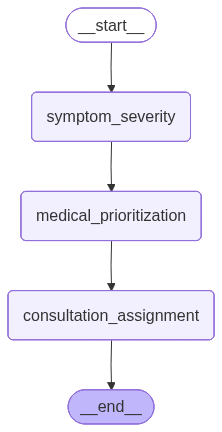

In [67]:
healthcare_workflow

In [69]:
print("\n--- Critical Scenario ---")
initial_state_critical: HealthcareState = {
    "patient_name": "Mubeen",
    "age": 65,
    "fever": 103.5,
    "oxygen_level": 88,
    "heart_rate": 130,
    "symptom_duration": 2,
    "existing_conditions": "Diabetes, Heart Disease",
    "severity_level": "",
    "appointment_priority": "",
    "consultation_type": ""
}
result_critical = healthcare_workflow.invoke(initial_state_critical)
print("Critical Case:", result_critical)

print("\n--- Moderate Scenario ---")
initial_state_moderate: HealthcareState = {
    "patient_name": "Naveen",
    "age": 40,
    "fever": 100.2,
    "oxygen_level": 92,
    "heart_rate": 105,
    "symptom_duration": 4,
    "existing_conditions": "Asthma",
    "severity_level": "",
    "appointment_priority": "",
    "consultation_type": ""
}
result_moderate = healthcare_workflow.invoke(initial_state_moderate)
print("Moderate Case:", result_moderate)

print("\n--- Stable Scenario ---")
initial_state_stable: HealthcareState = {
    "patient_name": "Ihsan",
    "age": 30,
    "fever": 98.6,
    "oxygen_level": 98,
    "heart_rate": 75,
    "symptom_duration": 1,
    "existing_conditions": "None",
    "severity_level": "",
    "appointment_priority": "",
    "consultation_type": ""
}
result_stable = healthcare_workflow.invoke(initial_state_stable)
print("Stable Case:", result_stable)


--- Critical Scenario ---
Critical Case: {'patient_name': 'Mubeen', 'age': 65, 'fever': 103.5, 'oxygen_level': 88, 'heart_rate': 130, 'symptom_duration': 2, 'existing_conditions': 'Diabetes, Heart Disease', 'severity_level': 'CRITICAL', 'appointment_priority': 'EMERGENCY', 'consultation_type': 'ICU/ER'}

--- Moderate Scenario ---
Moderate Case: {'patient_name': 'Naveen', 'age': 40, 'fever': 100.2, 'oxygen_level': 92, 'heart_rate': 105, 'symptom_duration': 4, 'existing_conditions': 'Asthma', 'severity_level': 'MODERATE', 'appointment_priority': 'PRIORITY_CONSULTATION', 'consultation_type': 'Specialist Doctor'}

--- Stable Scenario ---
Stable Case: {'patient_name': 'Ihsan', 'age': 30, 'fever': 98.6, 'oxygen_level': 98, 'heart_rate': 75, 'symptom_duration': 1, 'existing_conditions': 'None', 'severity_level': 'STABLE', 'appointment_priority': 'REGULAR_CONSULTATION', 'consultation_type': 'General Physician'}
